# Highest Closed DOT Contour + Highest Closed contour center  — Time Series


This notebook walks through finding the highest closed contour in the Dynamic Ocean Topography (DOT) field for a single timestep, step by step.

The approach:
1. Slice the dataset to the longitude range of interest
2. Prepare and mask the DOT field
3. Generate contours at many levels
4. Filter for closed contours only
5. Find the highest level that contains closed contours
6. Plot all closed sections at that level

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
crs = ccrs.PlateCarree()
import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature
from shapely.geometry import MultiPolygon
import geopandas as gpd
from shapely.geometry import box
import matplotlib.cm as cm
import pandas as pd
from shapely.affinity import translate
from matplotlib.path import Path
from scipy.interpolate import interpn
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
import numpy.ma as ma
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.ndimage import gaussian_filter
from scipy.stats import pearsonr
from pyproj import Geod
from shapely.geometry import Polygon
import numpy as np

import warnings

# Suppress only deprecation warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

workdir = '/Users/iw2g24/PycharmProjects/SLA_analysis/'
data_dir = workdir + 'Data/'
script_dir = workdir + 'Scripts/'
auxscriptdir = script_dir + 'aux_scripts/'
sys.path.append(auxscriptdir)
import aux_stereoplot as st
from geometry_izzyv1 import grad_sphere
clim_dir = data_dir + 'climate_indices/'

file_path = data_dir + 'dot_all_30bmedian_egm2008_sig3.nc'

ds = xr.open_dataset(file_path)
print(ds)
# print(ds)

start_time = '2011-01-01'
end_time = '2016-01-01'

ds = ds.sel(time=slice(start_time, end_time))
dot = ds['dot']
MDT = dot.mean(dim='time')
sla = dot - MDT
ds['sla'] = sla

gyre_name = 'ross' #ross #weddell #kerguelen
variable = 'dot' #'dot' #'sla'

# ---  cartopy directly to use local shapefiles ---
land_shp       = data_dir + 'ne_50m_land/ne_50m_land.shp'
coast_shp      = data_dir +'ne_50m_coastline/ne_50m_coastline.shp'
ice_poly_shp   = data_dir +'ne_50m_antarctic_ice_shelves_polys/ne_50m_antarctic_ice_shelves_polys.shp'
ice_lines_shp  = data_dir +'ne_50m_antarctic_ice_shelves_lines/ne_50m_antarctic_ice_shelves_lines.shp'

# --- Create cartopy features from your local files ---
land_feature      = cfeature.ShapelyFeature(shpreader.Reader(land_shp).geometries(),
                                             ccrs.PlateCarree(), facecolor='lightgray', edgecolor='none')
coast_feature     = cfeature.ShapelyFeature(shpreader.Reader(coast_shp).geometries(),
                                             ccrs.PlateCarree(), facecolor='none', edgecolor='black', linewidth=0.8)
ice_poly_feature  = cfeature.ShapelyFeature(shpreader.Reader(ice_poly_shp).geometries(),
                                             ccrs.PlateCarree(), facecolor='lightblue', edgecolor='none', alpha=0.5)
ice_lines_feature = cfeature.ShapelyFeature(shpreader.Reader(ice_lines_shp).geometries(),
                                             ccrs.PlateCarree(), facecolor='none', edgecolor='steelblue', linewidth=0.8)


# Load shapefiles as geodataframes
land_gdf = gpd.read_file(land_shp)
coast_gdf = gpd.read_file(coast_shp)
ice_poly_gdf = gpd.read_file(ice_poly_shp)
ice_lines_gdf = gpd.read_file(ice_lines_shp)

if gyre_name == 'ross':
    lon_min  = 150        # western boundary of your sector
    lon_max  =  -120  # eastern boundary of your sector
    lat_min = -90
    lat_max = -55
    crosses_dateline = True # set to False for normal sectors (<0 then >0)
elif gyre_name == 'weddell':
    lon_min = -80
    lon_max = 50
    lat_min = -90
    lat_max = -50
    crosses_dateline = False # set to False for normal sectors (<0 then >0)

time_idx =36          # index into ds.time — change to select a different month
n_levels = 300        # number of contour levels to test
min_area = 0.5        # minimum enclosed area (deg^2) to keep a contour

# # Cell 3 — add latitude to the slice
# crosses_dateline = True
if not crosses_dateline:
    # Original approach
    ds_slice = ds.sel(
        longitude=slice(lon_min, lon_max),
        latitude=slice(lat_min, lat_max),
        time=ds.time[time_idx]
    )
    lons = ds_slice['longitude'].values
    lats = ds_slice['latitude'].values
    var_2d  = ds_slice[variable].values.T
    land_2d = ds_slice['land_mask'].values.T

else:
    # Split into two chunks either side of the dateline and concatenate
    ds_A = ds.sel(
        longitude=slice(lon_min, 180),
        latitude=slice(lat_min, lat_max),
        time=ds.time[time_idx]
    )
    ds_B = ds.sel(
        longitude=slice(-180, lon_max),
        latitude=slice(lat_min, lat_max),
        time=ds.time[time_idx]
    )

    # Shift chunk B longitudes by +360 so the axis is monotonically increasing
    ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)

    # Concatenate along longitude
    # ds_slice = xr.concat([ds_A, ds_B], dim='longitude')
    ds_slice = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')

    lons = ds_slice['longitude'].values        # now runs e.g. 150 → 210 continuously
    lats = ds_slice['latitude'].values
    var_2d  = ds_slice[variable].values.T
    land_2d = ds_slice['land_mask'].values.T

# Mask land — same as before
var_2d = np.where(land_2d == 1, np.nan, var_2d)

print(f"Longitude range: {lons[0]:.1f} to {lons[-1]:.1f}  ({len(lons)} points)")

print('Making lat and lon grids...')
lon_grid, lat_grid = np.meshgrid(lons, lats)
print('made grids:', lon_grid.shape, lat_grid.shape)

<xarray.Dataset> Size: 193MB
Dimensions:          (longitude: 360, latitude: 64, time: 261, edge_lat: 65,
                      edge_lon: 361)
Coordinates:
  * longitude        (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * latitude         (latitude) float64 512B -81.75 -81.25 ... -50.75 -50.25
  * time             (time) datetime64[ns] 2kB 2002-09-01 ... 2024-12-01
  * edge_lat         (edge_lat) float64 520B -82.0 -81.5 -81.0 ... -50.5 -50.0
  * edge_lon         (edge_lon) float64 3kB -180.0 -179.0 -178.0 ... 179.0 180.0
Data variables:
    dot              (longitude, latitude, time) float64 48MB ...
    ug               (longitude, latitude, time) float64 48MB ...
    vg               (longitude, latitude, time) float64 48MB ...
    U                (longitude, latitude, time) float64 48MB ...
    land_mask        (longitude, latitude) float64 184kB ...
    intersat_offset  float64 8B ...
Attributes:
    history:      Created 20/05/2026, 14:1616
    description:  ENVISA

## load SAM variables

In [109]:
filename = clim_dir + 'SAM/' + 'sam_marshall_2024.txt'

years = []
monthly_vals = []


with open(filename) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 13:  # 1 year + 12 months
            years.append(int(parts[0]))
            monthly_vals.append([float(x) for x in parts[1:]])
        else:
            continue

sam_yrs = np.array(years)
sam_ind = ma.array(monthly_vals)  # shape (Nyears, 12)
sam_ind_1d = sam_ind.flatten()    # continuous monthly series

sam_ds = xr.open_dataset(clim_dir + 'SAM/' + 'sam_2000_2024.nc')
asl_ds = xr.open_dataset(clim_dir + 'ASL/' + 'ASL_2000_2025_data.nc')
soi_ds = xr.open_dataset(clim_dir + 'SOI/' + 'soi_2000_2024.nc')
zw3_ds = xr.open_dataset(clim_dir + 'ZW3/' + 'ZW3_2000_2024.nc')

## define functions for dateline fix

In [110]:
def split_and_shift_gdf(gdf, lons_shifted):
    x_min, x_max = lons_shifted[0], lons_shifted[-1]
    domain = box(x_min, lat_min, x_max, lat_max)

    # Keep both original and +360 shifted versions of every geometry
    original = gdf.copy()
    shifted  = gdf.copy()
    shifted['geometry'] = shifted.geometry.apply(lambda g: translate(g, xoff=360))

    combined = pd.concat([original, shifted])

    # Clip to domain — only geometries that fall within the domain survive
    combined['geometry'] = combined.geometry.apply(
        lambda g: g.intersection(domain) if g is not None and not g.is_empty else g
    )
    combined = combined[~combined.geometry.is_empty]
    return combined

def clip_gdf_to_domain(gdf, lon_min, lon_max, lat_min, lat_max):
    domain = box(lon_min, lat_min, lon_max, lat_max)
    clipped = gdf.copy()
    clipped['geometry'] = clipped.geometry.apply(
        lambda g: g.intersection(domain) if g is not None and not g.is_empty else g
    )
    clipped = clipped[~clipped.geometry.is_empty]
    return clipped

def is_valid_contour(verts, max_aspect_ratio=0.5):
    """
    Returns False if the contour is suspiciously meridional.
    max_aspect_ratio: reject if lon_span / lat_span < this value
    e.g. 0.5 means contour must be at least half as wide as it is tall
    """
    lon_span = verts[:, 0].max() - verts[:, 0].min()
    lat_span = verts[:, 1].max() - verts[:, 1].min()

    if lat_span == 0:
        return True   # flat contour, not meridional

    aspect = lon_span / lat_span
    return aspect >= max_aspect_ratio

def mean_inside_contour(verts, field_2d, lon_grid, lat_grid):
    """Compute mean of field_2d inside the closed contour verts."""
    path   = Path(verts)
    points = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])
    mask   = path.contains_points(points).reshape(field_2d.shape)
    vals   = field_2d[mask]
    return np.nanmean(vals) if len(vals) > 0 else np.nan

def area_deg2_to_km2(area_deg2, verts):
    """
    Convert area from degrees² to km² accounting for latitude.
    Uses the mean latitude of the contour vertices.
    """
    mean_lat = np.mean(verts[:, 1])
    # 1 degree latitude ≈ 111.32 km
    # 1 degree longitude ≈ 111.32 * cos(lat) km
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(mean_lat))
    return area_deg2 * km_per_deg_lat * km_per_deg_lon

def points_inside_contour(verts, lon_grid, lat_grid):
    """
    Returns a boolean 2D array (same shape as lon_grid / lat_grid) that is
    True for every grid point whose (lon, lat) lies inside the polygon
    defined by verts.
    """
    from matplotlib.path import Path
    path   = Path(verts)
    points = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])
    mask   = path.contains_points(points)
    return mask.reshape(lon_grid.shape), points

def sample_field_at_vertices(verts, var_2d, lon_grid, lat_grid):
    """
    Nearest-neighbour SSH sample at each contour vertex; returns the mean.
    """
    lons = lon_grid[0, :]
    lats = lat_grid[:, 0]
    vals = []
    for vx, vy in verts:
        ix = np.argmin(np.abs(lons - vx))
        iy = np.argmin(np.abs(lats - vy))
        v  = var_2d[iy, ix]
        if np.isfinite(v):
            vals.append(v)
    return np.mean(vals) if vals else np.nan

In [111]:
if crosses_dateline:
    _land      = split_and_shift_gdf(land_gdf, lons)
    _coast     = split_and_shift_gdf(coast_gdf, lons)
    _ice_poly  = split_and_shift_gdf(ice_poly_gdf, lons)
    _ice_lines = split_and_shift_gdf(ice_lines_gdf, lons)

else:
    _land      = clip_gdf_to_domain(land_gdf, lon_min, lon_max, lat_min, lat_max)
    _coast     = clip_gdf_to_domain(coast_gdf, lon_min, lon_max, lat_min, lat_max)
    _ice_poly  = clip_gdf_to_domain(ice_poly_gdf, lon_min, lon_max, lat_min, lat_max)
    _ice_lines = clip_gdf_to_domain(ice_lines_gdf, lon_min, lon_max, lat_min, lat_max)


## calculate contours for interpolated and smoothed (ross) regions

In [112]:
all_timestep_results = []


for time_idx_i, time_val in enumerate(ds.time.values):

    # --- Dateline-aware slice ---
    if not crosses_dateline:
        ds_slice_i = ds.sel(
            longitude=slice(lon_min, lon_max),
            latitude=slice(lat_min, lat_max),
            time=ds.time[time_idx_i]
        )
        lons_i = ds_slice_i['longitude'].values
        lats_i = ds_slice_i['latitude'].values
        var_2d_i  = ds_slice_i[variable].values.T

        # lat_mask_max = 'N/A'
        # lat_sigma = 'N/A'
        # lon_sigma = 'N/A'

        lat_mask_max = -50
        lat_sigma = 1
        lon_sigma = 3

        ssh_2d_i  = (ds_slice_i['dot'] + ds_slice_i['sla']).values.T
        land_2d_i = ds_slice_i['land_mask'].values.T

        mdt_2d_i  = MDT.sel(                                    # ← insert here
        longitude=slice(lon_min, lon_max),
        latitude=slice(lat_min, lat_max)
    ).values.T

    else:
        ds_A = ds.sel(longitude=slice(lon_min, 180),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds.sel(longitude=slice(-180, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
        # ds_slice_i = xr.concat([ds_A, ds_B], dim='longitude')
        ds_slice_i = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
        lons_i = ds_slice_i['longitude'].values
        lats_i = ds_slice_i['latitude'].values
        var_2d_i  = ds_slice_i[variable].values.T

        var_2d_unsmoothed = var_2d_i.copy()

        lat_mask_max = -70
        lat_sigma = 1
        lon_sigma = 3

        nan_mask = np.isnan(var_2d_i)
        var_filled = np.where(nan_mask, 0 , var_2d_i)
        weights = np.where(nan_mask, 0, 1 ).astype(float) #where nanmask is true = 0, where it is false = 1

        smoothed_vals = gaussian_filter(var_filled, sigma=(lat_sigma, lon_sigma))
        smoothed_weights = gaussian_filter(weights, sigma=(lat_sigma, lon_sigma))

        with np.errstate( invalid='ignore'):
            smoothed = np.where(smoothed_weights>0, smoothed_vals/ smoothed_weights, np.nan)

        # give mask S of 70˚
        lat_mask = lat_grid<lat_mask_max
        ocean_mask = ~np.isnan(var_2d_i)
        total_mask = lat_mask & ocean_mask
        var_2d_smoothed = np.where(total_mask, smoothed, var_2d_i)
        var_2d_i = var_2d_smoothed

        ssh_2d_i  = (ds_slice_i['dot'] + ds_slice_i['sla']).values.T
        land_2d_i = ds_slice_i['land_mask'].values.T

        mdt_A  = MDT.sel(longitude=slice(lon_min, 180),      # ← insert here
                        latitude=slice(lat_min, lat_max))
        mdt_B = MDT.sel(longitude=slice(-180, lon_max),
                            latitude=slice(lat_min, lat_max))
        mdt_B  = mdt_B.assign_coords(longitude=mdt_B.longitude.values + 360)
        mdt_2d_i  = xr.concat([mdt_A, mdt_B], dim='longitude').values.T

    # var_2d_i = np.where(land_2d_i == 1, np.nan, var_2d_i)
    # ssh_2d_i = np.where(land_2d_i == 1, np.nan, ssh_2d_i)
    lon_grid_i, lat_grid_i = np.meshgrid(lons_i, lats_i)


    """
    interpolating masked islands for Ross and Weddell Regions - sart of test
    """
    # --- Balleny Islands interpolation (Ross only) ---
    if gyre_name == 'ross':
        ball_lon_min, ball_lon_max = 156, 175
        ball_lat_min, ball_lat_max = -69, -60

        ball_lon_idx = np.where((lons_i >= ball_lon_min) & (lons_i <= ball_lon_max))[0]
        ball_lat_idx = np.where((lats_i >= ball_lat_min) & (lats_i <= ball_lat_max))[0]

        if len(ball_lon_idx) > 0 and len(ball_lat_idx) > 0:
            sub    = var_2d_i[np.ix_(ball_lat_idx, ball_lon_idx)]
            lons_b = lons_i[ball_lon_idx]
            lats_b = lats_i[ball_lat_idx]
            llon_b, llat_b = np.meshgrid(lons_b, lats_b)

            valid_b = ~np.isnan(sub)
            nan_b   = ~valid_b

            if valid_b.sum() >= 4 and nan_b.sum() > 0:
                src_pts = np.column_stack([llon_b[valid_b], llat_b[valid_b]])
                src_val = sub[valid_b]
                tgt_pts = np.column_stack([llon_b[nan_b],   llat_b[nan_b]])

                filled = griddata(src_pts, src_val, tgt_pts, method='linear')

                still_nan = np.isnan(filled)
                if still_nan.any():
                    filled[still_nan] = griddata(src_pts, src_val,
                                                 tgt_pts[still_nan], method='nearest')
                sub[nan_b] = filled
                var_2d_i[np.ix_(ball_lat_idx, ball_lon_idx)] = sub

    # --- Weddell island interpolation ---
    elif gyre_name == 'weddell':
        wed_lon_min, wed_lon_max = -30, -20
        wed_lat_min, wed_lat_max = -62, -50

        wed_lon_idx = np.where((lons_i >= wed_lon_min) & (lons_i <= wed_lon_max))[0]
        wed_lat_idx = np.where((lats_i >= wed_lat_min) & (lats_i <= wed_lat_max))[0]

        if len(wed_lon_idx) > 0 and len(wed_lat_idx) > 0:
            sub    = var_2d_i[np.ix_(wed_lat_idx, wed_lon_idx)]
            lons_b = lons_i[wed_lon_idx]
            lats_b = lats_i[wed_lat_idx]
            llon_b, llat_b = np.meshgrid(lons_b, lats_b)

            valid_b = ~np.isnan(sub)
            nan_b   = ~valid_b

            if valid_b.sum() >= 4 and nan_b.sum() > 0:
                src_pts = np.column_stack([llon_b[valid_b], llat_b[valid_b]])
                src_val = sub[valid_b]
                tgt_pts = np.column_stack([llon_b[nan_b],   llat_b[nan_b]])

                filled = griddata(src_pts, src_val, tgt_pts, method='linear')

                still_nan = np.isnan(filled)
                if still_nan.any():
                    filled[still_nan] = griddata(src_pts, src_val,
                                                 tgt_pts[still_nan], method='nearest')
                sub[nan_b] = filled
                var_2d_i[np.ix_(wed_lat_idx, wed_lon_idx)] = sub

    """
    interpolating masked islands for Ross and Weddell Regions - end of test
    """

    # --- Guard: skip if not enough valid data to contour ---
    var_min = np.nanmin(var_2d_i)
    var_max = np.nanmax(var_2d_i)
    if not np.isfinite(var_min) or not np.isfinite(var_max) or var_max <= var_min:
        print(f"Skipping {str(time_val)[:10]} — insufficient valid data")
        all_timestep_results.append({'time': time_val, 'time_idx': time_idx_i, 'found': False})
        continue

    levels_i = np.linspace(var_min, var_max, n_levels)

    fig, ax = plt.subplots()
    cs_i = ax.contour(lon_grid_i, lat_grid_i, var_2d_i, levels=levels_i)
    plt.close(fig)

    all_closed_i = []
    for level, segs in zip(cs_i.levels, cs_i.allsegs):
        for verts in segs:
            if len(verts) == 0:
                continue
            if np.allclose(verts[0], verts[-1], atol=1e-6):
                # x, y = verts[:, 0], verts[:, 1]
                # area = 0.5 * np.abs(
                #     np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))
                # )
                R_earth = 6371
                x, y = verts[:, 0], verts[:, 1] # lon/lat in degs
                x_rad, y_rad = x*(np.pi/180), y*(np.pi/180)
                # lat_mean_rad = np.mean(y_rad)
                x_cartesian = R_earth * x_rad* np.cos(y_rad)
                y_cartesian = R_earth * y_rad
                area = 0.5 * np.abs(
                    np.dot(x_cartesian, np.roll(y_cartesian, 1)) - np.dot(y_cartesian, np.roll(x_cartesian, 1))
                )

                # if area >= min_area and is_valid_contour(verts, max_aspect_ratio=0.5):
                #     all_closed_i.append((area, level, verts))
                if area >= min_area:
                    all_closed_i.append((area, level, verts))

    all_closed_i.sort(key=lambda t: t[0], reverse=True) #use largest area

    if all_closed_i:
        best = all_closed_i[0]
        best_verts = best[2]

        min_contour = min(all_closed_i, key=lambda t: t[1])
        min_level = min_contour[1]
        min_verts = min_contour[2]


        ssh_mean = mean_inside_contour(
        best_verts, ssh_2d_i, lon_grid_i, lat_grid_i
    )

        # MDT is a 2D spatial field on the same grid — mask it to the dataset's land mask
        mdt_mean = mean_inside_contour(
            best_verts, mdt_2d_i, lon_grid_i, lat_grid_i
        )

        all_timestep_results.append({
            'time'     : time_val,
            'time_idx' : time_idx_i,
            'area'     : best[0],
            'level'    : best[1],
            'verts'    : best[2],
            'area_km2' : best[0],
            'ssh_mean' : ssh_mean,
            'mdt_mean' : mdt_mean,       # ← add this
            'min_verts': min_verts,
            'min_level': min_level,
            'found'    : True
        })
    else:
        all_timestep_results.append({
            'time'    : time_val,
            'time_idx': time_idx_i,
            'found'   : False
        })

    if time_idx_i % 20 == 0:
        print(f"Processed {time_idx_i+1}/{len(ds.time.values)}  —  {str(time_val)[:10]}")

print(f"\nDone. {sum(r['found'] for r in all_timestep_results)} of {len(all_timestep_results)} timesteps have a closed contour.")

Processed 1/58  —  2011-01-01
Processed 21/58  —  2012-09-01
Processed 41/58  —  2014-08-01

Done. 58 of 58 timesteps have a closed contour.


In [113]:
# all_timestep_results = []
#
#
# for time_idx_i, time_val in enumerate(ds.time.values):
#
#     # --- Dateline-aware slice ---
#     if not crosses_dateline:
#         ds_slice_i = ds.sel(
#             longitude=slice(lon_min, lon_max),
#             latitude=slice(lat_min, lat_max),
#             time=ds.time[time_idx_i]
#         )
#         lons_i = ds_slice_i['longitude'].values
#         lats_i = ds_slice_i['latitude'].values
#         var_2d_i  = ds_slice_i[variable].values.T
#
#         lat_mask_max = 'N/A'
#         lat_sigma = 'N/A'
#         lon_sigma = 'N/A'
#
#         ssh_2d_i  = (ds_slice_i['dot'] + ds_slice_i['sla']).values.T
#         land_2d_i = ds_slice_i['land_mask'].values.T
#
#         mdt_2d_i  = MDT.sel(                                    # ← insert here
#         longitude=slice(lon_min, lon_max),
#         latitude=slice(lat_min, lat_max)
#     ).values.T
#
#     else:
#         ds_A = ds.sel(longitude=slice(lon_min, 180),
#                       latitude=slice(lat_min, lat_max),
#                       time=ds.time[time_idx_i])
#         ds_B = ds.sel(longitude=slice(-180, lon_max),
#                       latitude=slice(lat_min, lat_max),
#                       time=ds.time[time_idx_i])
#         ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
#         # ds_slice_i = xr.concat([ds_A, ds_B], dim='longitude')
#         ds_slice_i = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
#         lons_i = ds_slice_i['longitude'].values
#         lats_i = ds_slice_i['latitude'].values
#         var_2d_i  = ds_slice_i[variable].values.T
#
#         var_2d_unsmoothed = var_2d_i.copy()
#
#         lat_mask_max = -70
#         lat_sigma = 1
#         lon_sigma = 3
#
#         nan_mask = np.isnan(var_2d_i)
#         var_filled = np.where(nan_mask, 0 , var_2d_i)
#         weights = np.where(nan_mask, 0, 1 ).astype(float) #where nanmask is true = 0, where it is false = 1
#
#         smoothed_vals = gaussian_filter(var_filled, sigma=(lat_sigma, lon_sigma))
#         smoothed_weights = gaussian_filter(weights, sigma=(lat_sigma, lon_sigma))
#
#         with np.errstate( invalid='ignore'):
#             smoothed = np.where(smoothed_weights>0, smoothed_vals/ smoothed_weights, np.nan)
#
#         # give mask S of lat mask max (70˚S)
#         lat_mask = lat_grid<lat_mask_max
#         ocean_mask = ~np.isnan(var_2d_i)
#         total_mask = lat_mask & ocean_mask
#         var_2d_smoothed = np.where(total_mask, smoothed, var_2d_i)
#         var_2d_i = var_2d_smoothed
#
#         ssh_2d_i  = (ds_slice_i['dot'] + ds_slice_i['sla']).values.T
#         land_2d_i = ds_slice_i['land_mask'].values.T
#
#         mdt_A  = MDT.sel(longitude=slice(lon_min, 180),      # ← insert here
#                         latitude=slice(lat_min, lat_max))
#         mdt_B = MDT.sel(longitude=slice(-180, lon_max),
#                             latitude=slice(lat_min, lat_max))
#         mdt_B  = mdt_B.assign_coords(longitude=mdt_B.longitude.values + 360)
#         mdt_2d_i  = xr.concat([mdt_A, mdt_B], dim='longitude').values.T
#
#     lon_grid_i, lat_grid_i = np.meshgrid(lons_i, lats_i)
#
#
#     """
#     interpolating masked islands for Ross and Weddell Regions - sart of test
#     """
#     # --- Balleny Islands interpolation (Ross only) ---
#     if gyre_name == 'ross':
#         ball_lon_min, ball_lon_max = 156, 175
#         ball_lat_min, ball_lat_max = -69, -60
#
#         ball_lon_idx = np.where((lons_i >= ball_lon_min) & (lons_i <= ball_lon_max))[0]
#         ball_lat_idx = np.where((lats_i >= ball_lat_min) & (lats_i <= ball_lat_max))[0]
#
#         if len(ball_lon_idx) > 0 and len(ball_lat_idx) > 0:
#             sub= var_2d_i[np.ix_(ball_lat_idx, ball_lon_idx)]
#             lons_b = lons_i[ball_lon_idx]
#             lats_b = lats_i[ball_lat_idx]
#             llon_b, llat_b = np.meshgrid(lons_b, lats_b)
#
#             valid_b = ~np.isnan(sub)
#             nan_b   = ~valid_b
#
#             if valid_b.sum() >= 4 and nan_b.sum() > 0:
#                 src_pts = np.column_stack([llon_b[valid_b], llat_b[valid_b]])
#                 src_val = sub[valid_b]
#                 tgt_pts = np.column_stack([llon_b[nan_b],   llat_b[nan_b]])
#
#                 filled = griddata(src_pts, src_val, tgt_pts, method='linear')
#
#                 still_nan = np.isnan(filled)
#                 if still_nan.any():
#                     filled[still_nan] = griddata(src_pts, src_val,
#                                                  tgt_pts[still_nan], method='nearest')
#                 sub[nan_b] = filled
#                 var_2d_i[np.ix_(ball_lat_idx, ball_lon_idx)] = sub
#
#     # --- Weddell island interpolation ---
#     elif gyre_name == 'weddell':
#         wed_lon_min, wed_lon_max = -30, -20
#         wed_lat_min, wed_lat_max = -62, -50
#
#         wed_lon_idx = np.where((lons_i >= wed_lon_min) & (lons_i <= wed_lon_max))[0]
#         wed_lat_idx = np.where((lats_i >= wed_lat_min) & (lats_i <= wed_lat_max))[0]
#
#         if len(wed_lon_idx) > 0 and len(wed_lat_idx) > 0:
#             sub    = var_2d_i[np.ix_(wed_lat_idx, wed_lon_idx)]
#             lons_b = lons_i[wed_lon_idx]
#             lats_b = lats_i[wed_lat_idx]
#             llon_b, llat_b = np.meshgrid(lons_b, lats_b)
#
#             valid_b = ~np.isnan(sub)
#             nan_b   = ~valid_b
#
#             if valid_b.sum() >= 4 and nan_b.sum() > 0:
#                 src_pts = np.column_stack([llon_b[valid_b], llat_b[valid_b]])
#                 src_val = sub[valid_b]
#                 tgt_pts = np.column_stack([llon_b[nan_b],   llat_b[nan_b]])
#
#                 filled = griddata(src_pts, src_val, tgt_pts, method='linear')
#
#                 still_nan = np.isnan(filled)
#                 if still_nan.any():
#                     filled[still_nan] = griddata(src_pts, src_val,
#                                                  tgt_pts[still_nan], method='nearest')
#                 sub[nan_b] = filled
#                 var_2d_i[np.ix_(wed_lat_idx, wed_lon_idx)] = sub
#
#     """
#     interpolating masked islands for Ross and Weddell Regions - end of test
#     """
#
#     # --- Guard: skip if not enough valid data to contour ---
#     var_min = np.nanmin(var_2d_i)
#     var_max = np.nanmax(var_2d_i)
#     if not np.isfinite(var_min) or not np.isfinite(var_max) or var_max <= var_min:
#         print(f"Skipping {str(time_val)[:10]} — insufficient valid data")
#         all_timestep_results.append({'time': time_val, 'time_idx': time_idx_i, 'found': False})
#         continue
#
#     levels_i = np.linspace(var_min, var_max, n_levels)
#
#     fig, ax = plt.subplots()
#     cs_i = ax.contour(lon_grid_i, lat_grid_i, var_2d_i, levels=levels_i)
#     plt.close(fig)
#
#     all_closed_i = []
#     for level, segs in zip(cs_i.levels, cs_i.allsegs):
#         for verts in segs:
#             if len(verts) == 0:
#                 continue
#
#             if np.allclose(verts[0], verts[-1], atol=1e-6):
#                 lon = verts[:, 0]
#                 lat = verts[:, 1]
#                 # unwrap longitudes to avoid dateline jumps
#                 lon_unwrapped = np.unwrap(np.radians(lon)) * 180/np.pi
#                 # build polygon
#                 poly = Polygon(np.column_stack([lon_unwrapped, lat]))
#                 # fix self-intersections
#                 if not poly.is_valid:
#                     poly = poly.buffer(0)
#
#                 if poly.is_empty:
#                     continue
#
#                 lon_c, lat_c = poly.exterior.xy
#                 print('lon_c:', lon_c)
#                 print('lat_c:', lat_c)
#
#                 lon_c = np.asarray(lon_c)
#                 lat_c = np.asarray(lat_c)
#
#                 print('lon_c as array:', lon_c)
#                 print('lat_c as array:', lat_c)
#
#                 # compute ellipsoidal area
#                 # area_m2, _ = geod.polygon_area_perimeter(lon_c, lat_c)
#
#                 poly_c = Polygon(([lon_c, lat_c]))
#                 area_m2, _ = geod.polygon_area_perimeter(poly_c)
#
#                 area = abs(area_m2) / 1e6   # km²
#
#                 # keep only large enough contours
#                 if area >= min_area:
#                     all_closed_i.append((area, level, verts))
#
#
#     all_closed_i.sort(key=lambda t: t[0], reverse=True) #use largest area
#
#     if all_closed_i:
#         best = all_closed_i[0]
#         best_verts = best[2]
#
#         min_contour = min(all_closed_i, key=lambda t: t[1])
#         min_level = min_contour[1]
#         min_verts = min_contour[2]
#
#
#         ssh_mean = mean_inside_contour(
#         best_verts, ssh_2d_i, lon_grid_i, lat_grid_i
#     )
#
#         # MDT is a 2D spatial field on the same grid — mask it to the dataset's land mask
#         mdt_mean = mean_inside_contour(
#             best_verts, mdt_2d_i, lon_grid_i, lat_grid_i
#         )
#
#         all_timestep_results.append({
#             'time'     : time_val,
#             'time_idx' : time_idx_i,
#             'area'     : best[0],
#             'level'    : best[1],
#             'verts'    : best[2],
#             'area_km2' : best[0],
#             'ssh_mean' : ssh_mean,
#             'mdt_mean' : mdt_mean,       # ← add this
#             'min_verts': min_verts,
#             'min_level': min_level,
#             'found'    : True
#         })
#     else:
#         all_timestep_results.append({
#             'time'    : time_val,
#             'time_idx': time_idx_i,
#             'found'   : False
#         })
#
#     if time_idx_i % 20 == 0:
#         print(f"Processed {time_idx_i+1}/{len(ds.time.values)}  —  {str(time_val)[:10]}")
#
# print(f"\nDone. {sum(r['found'] for r in all_timestep_results)} of {len(all_timestep_results)} timesteps have a closed contour.")

In [114]:
# --- Options ---
# 'single'  : one timestep by index, e.g. plot_selection = 0
# 'range'   : a range of timestep indices, e.g. plot_selection = (0, 24)
# 'all'     : every timestep with a valid contour

plot_mode      = 'all'        # 'single', 'range', or 'all'
plot_selection = (3)        # used for 'single' (int) or 'range' (tuple)

# --- Build list of results to plot ---
if plot_mode == 'single':
    to_plot = all_timestep_results[plot_selection]
elif plot_mode == 'range':
    start, end = plot_selection
    to_plot = all_timestep_results[start:end+1]
elif plot_mode == 'all':
    to_plot = all_timestep_results

to_plot = [r for r in to_plot if r['found']]   # drop timesteps with no contour
print(f"Plotting {len(to_plot)} timestep(s)")

Plotting 58 timestep(s)


## multi-step contour and center plots

In [115]:
var_stack = []
for result in to_plot:
    if not crosses_dateline:
        ds_i = ds.sel(longitude=slice(lon_min, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[result['time_idx']])
        lons_i = ds_i['longitude'].values
        lats_i = ds_i['latitude'].values
        var_i  = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)
    else:
        ds_A = ds.sel(longitude=slice(lon_min, 180),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[result['time_idx']])
        ds_B = ds.sel(longitude=slice(-180, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[result['time_idx']])
        ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
        ds_i   = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
        lons_i = ds_i['longitude'].values
        lats_i = ds_i['latitude'].values
        var_i  = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)

    # --- Island interpolation for Ross / Weddell ---
    if gyre_name == 'ross':
        ex_lon_min, ex_lon_max = 156, 175
        ex_lat_min, ex_lat_max = -69, -60
    elif gyre_name == 'weddell':
        ex_lon_min, ex_lon_max = -30, -20
        ex_lat_min, ex_lat_max = -62, -50
    else:
        ex_lon_min = None  # no exclusion for kerguelen

    if ex_lon_min is not None:
        ex_lon_idx = np.where((lons_i >= ex_lon_min) & (lons_i <= ex_lon_max))[0]
        ex_lat_idx = np.where((lats_i >= ex_lat_min) & (lats_i <= ex_lat_max))[0]

        if len(ex_lon_idx) > 0 and len(ex_lat_idx) > 0:
            sub    = var_i[np.ix_(ex_lat_idx, ex_lon_idx)]
            lons_b = lons_i[ex_lon_idx]
            lats_b = lats_i[ex_lat_idx]
            llon_b, llat_b = np.meshgrid(lons_b, lats_b)

            valid_b = ~np.isnan(sub)
            nan_b   = ~valid_b

            if valid_b.sum() >= 4 and nan_b.sum() > 0:
                src_pts = np.column_stack([llon_b[valid_b], llat_b[valid_b]])
                src_val = sub[valid_b]
                tgt_pts = np.column_stack([llon_b[nan_b],   llat_b[nan_b]])

                filled = griddata(src_pts, src_val, tgt_pts, method='linear')

                still_nan = np.isnan(filled)
                if still_nan.any():
                    filled[still_nan] = griddata(src_pts, src_val,
                                                 tgt_pts[still_nan], method='nearest')
                sub[nan_b] = filled
                var_i[np.ix_(ex_lat_idx, ex_lon_idx)] = sub

    var_stack.append(var_i)

# capture reference lon/lat from the last iteration
lons_ref = lons_i
lats_ref = lats_i

var_mean = np.nanmean(np.stack(var_stack, axis=0), axis=0)
lon_grid_ref, lat_grid_ref = np.meshgrid(lons_ref, lats_ref)

In [116]:
# calculate the gyre centres

In [117]:
# gyre_centres = []
#
# for result in to_plot:
#     time_idx_i = result['time_idx']
#
#     # --- Dateline-aware slice ---
#     if not crosses_dateline:
#         ds_i = ds.sel(longitude=slice(lon_min, lon_max),
#                       latitude=slice(lat_min, lat_max),
#                       time=ds.time[time_idx_i])
#         lons_i = ds_i['longitude'].values
#         lats_i = ds_i['latitude'].values
#         var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)
#     else:
#         ds_A = ds.sel(longitude=slice(lon_min, 180),
#                       latitude=slice(lat_min, lat_max),
#                       time=ds.time[time_idx_i])
#         ds_B = ds.sel(longitude=slice(-180, lon_max),
#                       latitude=slice(lat_min, lat_max),
#                       time=ds.time[time_idx_i])
#         ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
#         ds_i  = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
#         lons_i = ds_i['longitude'].values
#         lats_i = ds_i['latitude'].values
#         var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)
#
#         land_2d_i  = ds_i['land_mask'].values.T
#
#         total_mask = (land_2d_i == 0)
#         var_filled = np.where(total_mask, var_2d_i, 0.0)
#         weights    = np.where(total_mask, 1.0, 0.0)
#         smoothed_vals    = gaussian_filter(var_filled, sigma=(lat_sigma, lon_sigma))
#         smoothed_weights = gaussian_filter(weights,    sigma=(lat_sigma, lon_sigma))
#         smoothed         = np.where(smoothed_weights > 0, smoothed_vals / smoothed_weights, np.nan)
#         var_2d_smoothed  = np.where(total_mask, smoothed, var_2d_i)
#         var_2d_i         = np.where(land_2d_i == 1, np.nan, var_2d_smoothed)
#
#     lon_grid_i, lat_grid_i = np.meshgrid(lons_i, lats_i)
#
#     # --- Minimum DOT inside the contour only ---
#     verts_i    = result['verts']
#     mask_i , _    = points_inside_contour(verts_i, lon_grid_i, lat_grid_i)
#     var_masked = np.where(mask_i, var_2d_i, np.nan)
#
#     min_idx    = np.unravel_index(np.nanargmin(var_masked), var_masked.shape)
#     centre_lon = lon_grid_i[min_idx]
#     centre_lat = lat_grid_i[min_idx]
#     centre_var = var_masked[min_idx]
#
#     gyre_centres.append({
#         'time'      : result['time'],
#         'time_idx'  : time_idx_i,
#         'centre_lon': centre_lon,
#         'centre_lat': centre_lat,
#         'centre_var': centre_var,
#     })
#
# print(f"Gyre centre computed for {len(gyre_centres)} timesteps.")
#
# # --- Spatial plot ---
# fig, ax = plt.subplots(figsize=(13, 6))
#
# # Background
# ref = to_plot[0]
# if not crosses_dateline:
#     ds_ref = ds.sel(longitude=slice(lon_min, lon_max),
#                     latitude=slice(lat_min, lat_max),
#                     time=ds.time[ref['time_idx']])
#     lons_ref = ds_ref['longitude'].values
#     lats_ref = ds_ref['latitude'].values
#     var_ref  = np.where(ds_ref['land_mask'].values.T == 1, np.nan, ds_ref[variable].values.T)
# else:
#     ds_A = ds.sel(longitude=slice(lon_min, 180),
#                   latitude=slice(lat_min, lat_max),
#                   time=ds.time[ref['time_idx']])
#     ds_B = ds.sel(longitude=slice(-180, lon_max),
#                   latitude=slice(lat_min, lat_max),
#                   time=ds.time[ref['time_idx']])
#     ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
#     ds_ref = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
#     lons_ref = ds_ref['longitude'].values
#     lats_ref = ds_ref['latitude'].values
#     var_ref  = np.where(ds_ref['land_mask'].values.T == 1, np.nan, ds_ref[variable].values.T)
#
# lon_grid_ref, lat_grid_ref = np.meshgrid(lons_ref, lats_ref)
# pcm = ax.pcolormesh(lon_grid_ref, lat_grid_ref, var_mean, cmap='RdBu_r', shading='auto', alpha=0.7, zorder=1)
#
# # Shapefiles
# _land.plot(ax=ax,      color='lightgray', edgecolor='none',  zorder=2)
# _coast.plot(ax=ax,     color='none',      edgecolor='black', linewidth=0.8, zorder=3)
# _ice_poly.plot(ax=ax,  color='lightblue', edgecolor='none',  alpha=0.5, zorder=2)
# _ice_lines.plot(ax=ax, color='steelblue', edgecolor='none',  linewidth=0.8, zorder=3)
#
# ax.set_aspect('auto')
# ax.set_xlim(lons_ref[0], lons_ref[-1])
# ax.set_ylim(lat_min, lat_max)
#
# if crosses_dateline:
#     tick_vals = np.arange(np.ceil(lons_ref[0]/10)*10, lons_ref[-1]+1, 30)
#     ax.set_xticks(tick_vals)
#     ax.set_xticklabels([f'{int(x-360)}°E' if x > 180 else f'{int(x)}°E' for x in tick_vals])
#
# # Gyre centre scatter — colour-mapped by timestep index
# cmap_t = cm.viridis
# n      = len(gyre_centres)
#
# for i, centre in enumerate(gyre_centres):
#     color = cmap_t(i / max(n - 1, 1))
#     ax.scatter(
#         centre['centre_lon'], centre['centre_lat'],
#         color=color, s=20, zorder=5, linewidths=0
#     )
#
# sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(0, n - 1))
# sm.set_array([])
# cbar_t = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, fraction=0.02)
# cbar_t.set_label('Timestep index')
# plt.colorbar(pcm, ax=ax, label=f'{variable} (m)', orientation='horizontal', pad=0.12)
#
# if plot_mode == 'single':
#     ax.set_title(f'Gyre Centre Location using {variable}\n{str(to_plot[0]["time"])[:10]}')
# elif plot_mode == 'range':
#     ax.set_title(f'Gyre Centre Locations using {variable} — {str(to_plot[0]["time"])[:10]} to {str(to_plot[-1]["time"])[:10]}')
# else:
#     ax.set_title(f'Gyre Centre Locations using {variable} — All Timesteps')
#
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')
# plt.tight_layout()
# plt.show()

In [118]:
# gyre centroid - useful for gyre assymetry

Gyre centre computed for 58 timesteps.


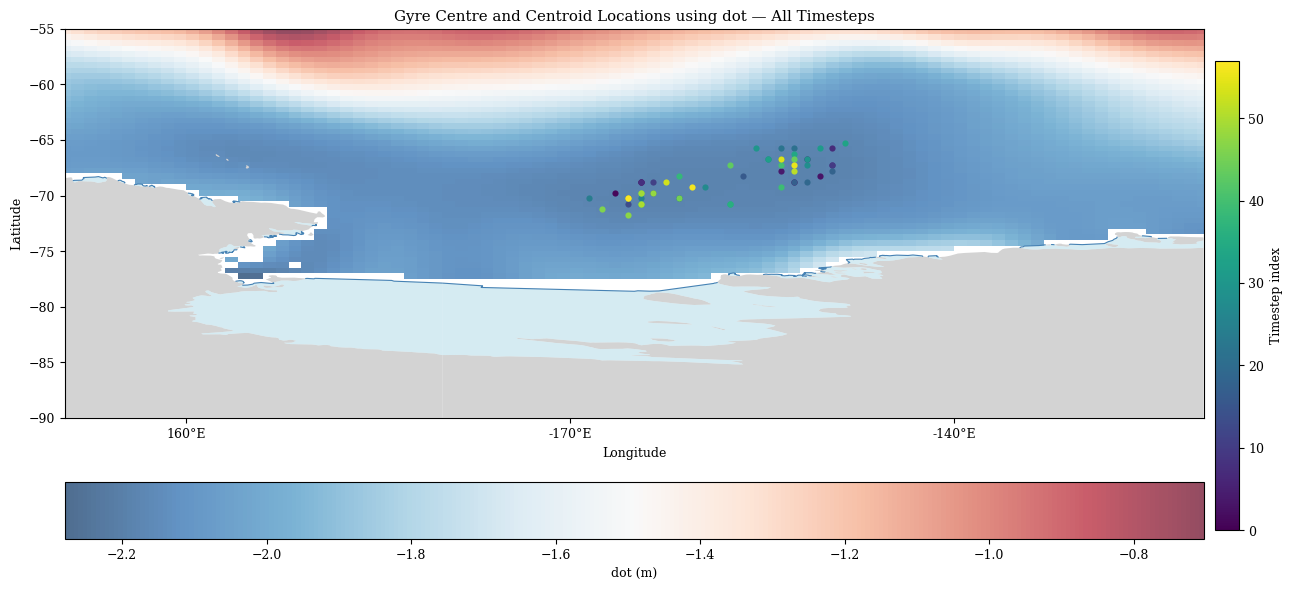

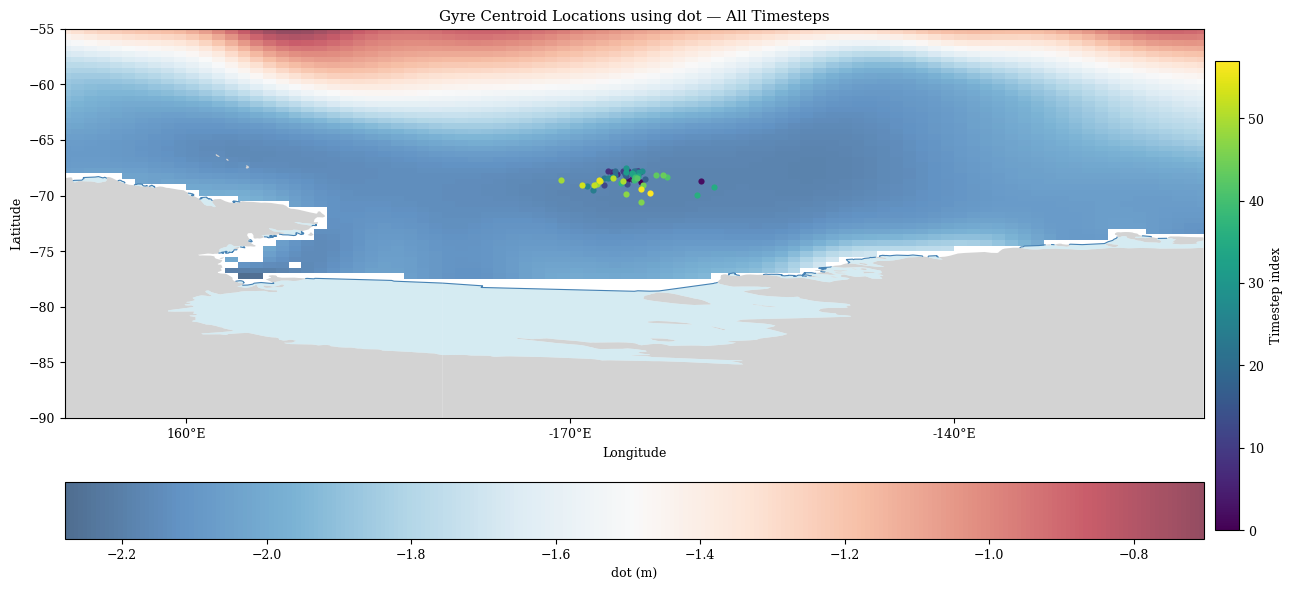

In [119]:
gyre_centres = []

for result in to_plot:
    time_idx_i = result['time_idx']

    # --- Dateline-aware slice ---
    if not crosses_dateline:
        ds_i = ds.sel(longitude=slice(lon_min, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        lons_i = ds_i['longitude'].values
        lats_i = ds_i['latitude'].values
        var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)
    else:
        ds_A = ds.sel(longitude=slice(lon_min, 180),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds.sel(longitude=slice(-180, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
        ds_i  = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
        lons_i = ds_i['longitude'].values
        lats_i = ds_i['latitude'].values
        var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)

        land_2d_i  = ds_i['land_mask'].values.T

        total_mask = (land_2d_i == 0)
        var_filled = np.where(total_mask, var_2d_i, 0.0)
        weights    = np.where(total_mask, 1.0, 0.0)
        smoothed_vals    = gaussian_filter(var_filled, sigma=(lat_sigma, lon_sigma))
        smoothed_weights = gaussian_filter(weights,    sigma=(lat_sigma, lon_sigma))
        smoothed         = np.where(smoothed_weights > 0, smoothed_vals / smoothed_weights, np.nan)
        var_2d_smoothed  = np.where(total_mask, smoothed, var_2d_i)
        var_2d_i         = np.where(land_2d_i == 1, np.nan, var_2d_smoothed)

    lon_grid_i, lat_grid_i = np.meshgrid(lons_i, lats_i)

    # --- Minimum DOT inside the contour only ---
    verts_i    = result['verts']
    mask_i, points_i     = points_inside_contour(verts_i, lon_grid_i, lat_grid_i)
    var_masked = np.where(mask_i, var_2d_i, np.nan)

    # gyre centroid
    mask_flat = np.ravel(mask_i)
    lon_i = points_i[..., 0][mask_flat]
    lat_i = points_i[..., 1][mask_flat]
    dot_i = var_masked[mask_i]
    weights_i =  - dot_i # have the negative sign here to pull the centroid towards the min DOT values (as is the case for weddell and ross gyres)

    lon_centroid = np.nansum(lon_i*weights_i)/np.nansum(weights_i)
    lat_centroid = np.nansum(lat_i*weights_i)/np.nansum(weights_i)

    # gyre center
    min_idx    = np.unravel_index(np.nanargmin(var_masked), var_masked.shape)
    centre_lon = lon_grid_i[min_idx]
    centre_lat = lat_grid_i[min_idx]
    centre_var = var_masked[min_idx]

    gyre_centres.append({
        'time'      : result['time'],
        'time_idx'  : time_idx_i,
        'centre_lon': centre_lon,
        'centre_lat': centre_lat,
        'centre_var': centre_var,
        'centroid_lon': lon_centroid,
        'centroid_lat': lat_centroid,
    })

print(f"Gyre centre computed for {len(gyre_centres)} timesteps.")

# --- Spatial plot ---
fig, ax = plt.subplots(figsize=(13, 6))

# Background
ref = to_plot[0]
if not crosses_dateline:
    ds_ref = ds.sel(longitude=slice(lon_min, lon_max),
                    latitude=slice(lat_min, lat_max),
                    time=ds.time[ref['time_idx']])
    lons_ref = ds_ref['longitude'].values
    lats_ref = ds_ref['latitude'].values
    var_ref  = np.where(ds_ref['land_mask'].values.T == 1, np.nan, ds_ref[variable].values.T)
else:
    ds_A = ds.sel(longitude=slice(lon_min, 180),
                  latitude=slice(lat_min, lat_max),
                  time=ds.time[ref['time_idx']])
    ds_B = ds.sel(longitude=slice(-180, lon_max),
                  latitude=slice(lat_min, lat_max),
                  time=ds.time[ref['time_idx']])
    ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
    ds_ref = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
    lons_ref = ds_ref['longitude'].values
    lats_ref = ds_ref['latitude'].values
    var_ref  = np.where(ds_ref['land_mask'].values.T == 1, np.nan, ds_ref[variable].values.T)

lon_grid_ref, lat_grid_ref = np.meshgrid(lons_ref, lats_ref)
pcm = ax.pcolormesh(lon_grid_ref, lat_grid_ref, var_mean, cmap='RdBu_r', shading='auto', alpha=0.7, zorder=1)

# Shapefiles
_land.plot(ax=ax,      color='lightgray', edgecolor='none',  zorder=2)
_coast.plot(ax=ax,     color='none',      edgecolor='black', linewidth=0.8, zorder=3)
_ice_poly.plot(ax=ax,  color='lightblue', edgecolor='none',  alpha=0.5, zorder=2)
_ice_lines.plot(ax=ax, color='steelblue', edgecolor='none',  linewidth=0.8, zorder=3)

ax.set_aspect('auto')
ax.set_xlim(lons_ref[0], lons_ref[-1])
ax.set_ylim(lat_min, lat_max)

if crosses_dateline:
    tick_vals = np.arange(np.ceil(lons_ref[0]/10)*10, lons_ref[-1]+1, 30)
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([f'{int(x-360)}°E' if x > 180 else f'{int(x)}°E' for x in tick_vals])

# Gyre centre scatter — colour-mapped by timestep index
cmap_t = cm.viridis
n      = len(gyre_centres)

for i, centre in enumerate(gyre_centres):
    color = cmap_t(i / max(n - 1, 1))
    ax.scatter(
        centre['centre_lon'], centre['centre_lat'],
        color=color, s=20, zorder=5, linewidths=0
    )

sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(0, n - 1))
sm.set_array([])
cbar_t = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, fraction=0.02)
cbar_t.set_label('Timestep index')
plt.colorbar(pcm, ax=ax, label=f'{variable} (m)', orientation='horizontal', pad=0.12)

if plot_mode == 'single':
    ax.set_title(f'Gyre Centre and Centroid Location using {variable}\n{str(to_plot[0]["time"])[:10]}')
elif plot_mode == 'range':
    ax.set_title(f'Gyre Centre and Centroid Locations using {variable} — {str(to_plot[0]["time"])[:10]} to {str(to_plot[-1]["time"])[:10]}')
else:
    ax.set_title(f'Gyre Centre and Centroid Locations using {variable} — All Timesteps')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()


# --- Spatial plot ---
fig, ax = plt.subplots(figsize=(13, 6))

# Background
ref = to_plot[0]
if not crosses_dateline:
    ds_ref = ds.sel(longitude=slice(lon_min, lon_max),
                    latitude=slice(lat_min, lat_max),
                    time=ds.time[ref['time_idx']])
    lons_ref = ds_ref['longitude'].values
    lats_ref = ds_ref['latitude'].values
    var_ref  = np.where(ds_ref['land_mask'].values.T == 1, np.nan, ds_ref[variable].values.T)
else:
    ds_A = ds.sel(longitude=slice(lon_min, 180),
                  latitude=slice(lat_min, lat_max),
                  time=ds.time[ref['time_idx']])
    ds_B = ds.sel(longitude=slice(-180, lon_max),
                  latitude=slice(lat_min, lat_max),
                  time=ds.time[ref['time_idx']])
    ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
    ds_ref = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
    lons_ref = ds_ref['longitude'].values
    lats_ref = ds_ref['latitude'].values
    var_ref  = np.where(ds_ref['land_mask'].values.T == 1, np.nan, ds_ref[variable].values.T)

lon_grid_ref, lat_grid_ref = np.meshgrid(lons_ref, lats_ref)
pcm = ax.pcolormesh(lon_grid_ref, lat_grid_ref, var_mean, cmap='RdBu_r', shading='auto', alpha=0.7, zorder=1)

# Shapefiles
_land.plot(ax=ax,      color='lightgray', edgecolor='none',  zorder=2)
_coast.plot(ax=ax,     color='none',      edgecolor='black', linewidth=0.8, zorder=3)
_ice_poly.plot(ax=ax,  color='lightblue', edgecolor='none',  alpha=0.5, zorder=2)
_ice_lines.plot(ax=ax, color='steelblue', edgecolor='none',  linewidth=0.8, zorder=3)

ax.set_aspect('auto')
ax.set_xlim(lons_ref[0], lons_ref[-1])
ax.set_ylim(lat_min, lat_max)

if crosses_dateline:
    tick_vals = np.arange(np.ceil(lons_ref[0]/10)*10, lons_ref[-1]+1, 30)
    ax.set_xticks(tick_vals)
    ax.set_xticklabels([f'{int(x-360)}°E' if x > 180 else f'{int(x)}°E' for x in tick_vals])

# Gyre centre scatter — colour-mapped by timestep index
cmap_t = cm.viridis
n      = len(gyre_centres)

for i, centre in enumerate(gyre_centres):
    color = cmap_t(i / max(n - 1, 1))
    ax.scatter(
        centre['centroid_lon'], centre['centroid_lat'],
        color=color, s=20, zorder=5, linewidths=0
    )

sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(0, n - 1))
sm.set_array([])
cbar_t = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.01, fraction=0.02)
cbar_t.set_label('Timestep index')
plt.colorbar(pcm, ax=ax, label=f'{variable} (m)', orientation='horizontal', pad=0.12)

if plot_mode == 'single':
    ax.set_title(f'Gyre Centroid Location using {variable}\n{str(to_plot[0]["time"])[:10]}')
elif plot_mode == 'range':
    ax.set_title(f'Gyre Centroid Locations using {variable} — {str(to_plot[0]["time"])[:10]} to {str(to_plot[-1]["time"])[:10]}')
else:
    ax.set_title(f'Gyre Centroid Locations using {variable} — All Timesteps')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## calculate spatial (lateral) gradient of DOT - this can be used for intensity (Heather Reagan, 2019)

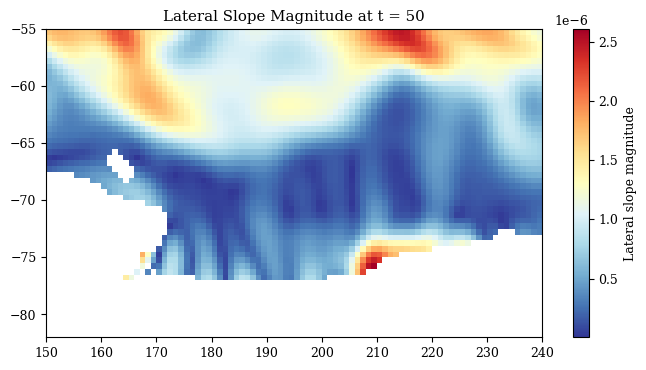

In [120]:
# # # calculate gradients on a sphere
# # df_dx , df_dy = grad_sphere(var_2d_i, lon_grid, lat_grid)
# # # calcualte the magnitude of the lateral slope
# # lateral_slope = np.sqrt((df_dx**2 + df_dy**2))
# # print(lateral_slope.shape)
#
# # plt.pcolormesh(lon_grid, lat_grid, lateral_slope, cmap='RdBu_r')
#
# lateral_slope = []
#
# for result in to_plot:
#     time_idx_i = result['time_idx']
#
#     # --- Dateline-aware slice ---
#     if not crosses_dateline:
#         ds_i = ds.sel(longitude=slice(lon_min, lon_max),
#                       latitude=slice(lat_min, lat_max),
#                       time=ds.time[time_idx_i])
#         lons_i = ds_i['longitude'].values
#         lats_i = ds_i['latitude'].values
#         var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)
#     else:
#         ds_A = ds.sel(longitude=slice(lon_min, 180),
#                       latitude=slice(lat_min, lat_max),
#                       time=ds.time[time_idx_i])
#         ds_B = ds.sel(longitude=slice(-180, lon_max),
#                       latitude=slice(lat_min, lat_max),
#                       time=ds.time[time_idx_i])
#         ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
#         ds_i  = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
#         lons_i = ds_i['longitude'].values
#         lats_i = ds_i['latitude'].values
#         var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)
#
#         land_2d_i  = ds_i['land_mask'].values.T
#
#         total_mask = (land_2d_i == 0)
#         var_filled = np.where(total_mask, var_2d_i, 0.0)
#         weights    = np.where(total_mask, 1.0, 0.0)
#         smoothed_vals    = gaussian_filter(var_filled, sigma=(lat_sigma, lon_sigma))
#         smoothed_weights = gaussian_filter(weights,    sigma=(lat_sigma, lon_sigma))
#         smoothed         = np.where(smoothed_weights > 0, smoothed_vals / smoothed_weights, np.nan)
#         var_2d_smoothed  = np.where(total_mask, smoothed, var_2d_i)
#         var_2d_i         = np.where(land_2d_i == 1, np.nan, var_2d_smoothed)
#
#     lon_grid_i, lat_grid_i = np.meshgrid(lons_i, lats_i)
#     df_dx_i , df_dy_i = grad_sphere(var_2d_i, lon_grid_i, lat_grid_i)
#     # calcualte the magnitude of the lateral slope
#     lateral_slope_i = np.sqrt((df_dx_i**2 + df_dy_i**2))
#
#     lateral_slope.append({
#         'time': result['time'],
#         'lateral_slope': lateral_slope_i,
#         'lon_grid_i': lon_grid_i,
#         'lat_grid_i': lat_grid_i,
#     })

lateral_slope = []

for result in to_plot:
    time_idx_i = result['time_idx']

    if not crosses_dateline:
        ds_i = ds.sel(longitude=slice(lon_min, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        lons_i = ds_i['longitude'].values
        lats_i = ds_i['latitude'].values
        var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)

    else:
        ds_A = ds.sel(longitude=slice(lon_min, 180),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds.sel(longitude=slice(-180, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
        ds_i  = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
        lons_i = ds_i['longitude'].values
        lats_i = ds_i['latitude'].values
        var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)

        land_2d_i = ds_i['land_mask'].values.T

        # # --- smoothing: latitude-limited, matching the contour loop ---
        # nan_mask = np.isnan(var_2d_i)
        # var_filled = np.where(nan_mask, 0, var_2d_i)
        # weights = np.where(nan_mask, 0, 1).astype(float)
        # smoothed_vals    = gaussian_filter(var_filled, sigma=(lat_sigma, lon_sigma))
        # smoothed_weights = gaussian_filter(weights,    sigma=(lat_sigma, lon_sigma))
        # with np.errstate(invalid='ignore'):
        #     smoothed = np.where(smoothed_weights > 0, smoothed_vals / smoothed_weights, np.nan)

        lon_grid_i, lat_grid_i = np.meshgrid(lons_i, lats_i)
        lat_mask   = lat_grid_i < lat_mask_max   # only south of -70°S
        ocean_mask = ~np.isnan(var_2d_i)
        total_mask = lat_mask & ocean_mask
        var_2d_i = np.where(ocean_mask,  var_2d_i, np.nan)

    lon_grid_i, lat_grid_i = np.meshgrid(lons_i, lats_i)
    df_dx_i, df_dy_i = grad_sphere(var_2d_i, lon_grid_i, lat_grid_i)
    lateral_slope_i = np.sqrt((df_dx_i**2 + df_dy_i**2))

    lateral_slope.append({
        'time': result['time'],
        'lateral_slope': lateral_slope_i,
        'lon_grid_i': lon_grid_i,
        'lat_grid_i': lat_grid_i,
    })

plot_index = 50
lateral_slope_t = lateral_slope[ plot_index]['lateral_slope']
lon_grid_t = lateral_slope[ plot_index]['lon_grid_i']
lat_grid_t = lateral_slope[ plot_index]['lat_grid_i']

plt.figure(figsize=(8, 4))
plt.pcolormesh(lon_grid_t, lat_grid_t, lateral_slope_t, cmap='RdYlBu_r')
plt.colorbar(label = 'Lateral slope magnitude')
plt.title(f'Lateral Slope Magnitude at t = {plot_index}')
plt.show()


## define funcs for stereo contours/centers

In [121]:
def spstere_plot_gyre_contours(ax, m_sec, wedge_patch,
                               to_plot, plot_mode='all', variable='dot', lat_mask_max = lat_mask_max, white_contours = False):
    """
    Overlay largest-closed gyre contours onto an existing spstere_plot_sector axes.

    Parameters
    ----------
    ax, m_sec, wedge_patch : returned by spstere_plot_sector (remember to update
                             spstere_plot_sector's return to:
                             return fig, ax, m_sec, wedge_patch)
    to_plot    : list of dicts with keys 'verts', 'time', 'time_idx'
    plot_mode  : 'single' | 'range' | 'all'
    variable   : variable name string used in title
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm

    cmap_t = cm.viridis
    n      = len(to_plot)

    for i, result in enumerate(to_plot):
        if white_contours:
            color = 'white'
        else:
            color = cmap_t(i / max(n - 1, 1))
        label = str(result['time'])[:10] if plot_mode in ('single', 'range') and n <= 12 else None

        lon_v = result['verts'][:, 0] % 360   # ensure 0–360
        lat_v = result['verts'][:, 1]

        x_v, y_v = m_sec(lon_v, lat_v)

        # mask Basemap sentinel values
        valid = (np.abs(x_v) < 1e29) & (np.abs(y_v) < 1e29)
        if valid.sum() < 3:
            continue

        lines = ax.plot(
            x_v[valid], y_v[valid],
            color=color, linewidth=1.5, alpha=0.85,
            label=label, zorder=7
        )
        for line in lines:
            line.set_clip_path(wedge_patch)
            line.set_clip_on(True)

    # timestep colourbar
    if not white_contours:
        sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(0, n - 1))
        sm.set_array([])
        fig = ax.get_figure()
        cbar_t = fig.colorbar(sm, ax=ax, orientation='vertical',
                              pad=0.01, fraction=0.03, shrink=0.6)
        cbar_t.set_label('Timestep index', fontsize=9)

    # title
    if plot_mode == 'single':
        title = f'Largest Closed {variable} Contour\n{str(to_plot[0]["time"])[:10]}\nlat_mask = {lat_mask_max}, sig lat = {lat_sigma}, sig lon = {lon_sigma}'
    elif plot_mode == 'range':
        title = (f'Largest Closed {variable} Contours\n'
                 f'{str(to_plot[0]["time"])[:10]} – {str(to_plot[-1]["time"])[:10]}\nlat_mask = {lat_mask_max}, sig lat = {lat_sigma}, sig lon = {lon_sigma}')
    else:
        title = f'Largest Closed {variable} Contours — All Timesteps\nlat_mask = {lat_mask_max}, sig lat = {lat_sigma}, sig lon = {lon_sigma}'

    fig = ax.get_figure()
    if gyre_name == 'ross':
        fig.suptitle(title, fontsize=12, fontweight='bold', y=0.98)
        fig.subplots_adjust(top=0.92)
    else:
        fig.suptitle(title, fontsize=12, fontweight='bold', y=0.95)
        fig.subplots_adjust(top=0.92)


    if plot_mode in ('single', 'range') and n <= 12:
        ax.legend(loc='lower left', fontsize=7, framealpha=0.85)

def spstere_mean_contour_plot(ax, m_sec, wedge_patch, mean_verts, color = 'black', linewidth = 2, linestyle = '--', label = 'Mean Contour'):

    lon_v = mean_verts[:, 0] % 360   # ensure 0–360
    lat_v = mean_verts[:, 1]
    x_v, y_v = m_sec(lon_v, lat_v)
    valid = (np.abs(x_v) < 1e29) & (np.abs(y_v) < 1e29)

    if valid.sum() < 3:
        return

    lines = ax.plot(
            x_v[valid], y_v[valid],
            color=color, linewidth=linewidth, linestyle = linestyle, alpha=0.85,
            label=label, zorder=7
        )
    for line in lines:
        line.set_clip_path(wedge_patch)
        line.set_clip_on(True)
    ax.legend(loc='lower left', fontsize=7, framealpha=0.95)

def spstere_plot_gyre_centres(ax, m_sec, wedge_patch,
                              gyre_centres, plot_mode='all', variable='dot'):
    """
    Overlay gyre centre locations (scatter) onto an existing spstere_plot_sector axes.

    Parameters
    ----------
    ax, m_sec, wedge_patch : returned by spstere_plot_sector
    gyre_centres : list of dicts with keys 'centre_lon', 'centre_lat',
                   'centre_var', 'time', 'time_idx'
    plot_mode    : 'single' | 'range' | 'all'
    variable     : variable name string used in title
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm

    cmap_t = cm.viridis
    n      = len(gyre_centres)

    for i, centre in enumerate(gyre_centres):
        color = cmap_t(i / max(n - 1, 1))

        lon_c = centre['centre_lon'] % 360
        lat_c = centre['centre_lat']

        x_c, y_c = m_sec(lon_c, lat_c)

        # skip sentinel values
        if abs(x_c) > 1e29 or abs(y_c) > 1e29:
            continue

        sc = ax.scatter(x_c, y_c, color=color, s=25, zorder=8,
                        linewidths=0, clip_on=True)
        sc.set_clip_path(wedge_patch)

    # timestep colourbar
    sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(0, n - 1))
    sm.set_array([])
    fig = ax.get_figure()
    cbar_t = fig.colorbar(sm, ax=ax, orientation='vertical',
                          pad=0.02, fraction=0.03, shrink=0.6)
    cbar_t.set_label('Timestep index', fontsize=9)

    # title
    if plot_mode == 'single':
        title = f'Gyre Centre ({variable})\n{str(gyre_centres[0]["time"])[:10]}\nlat_mask = {lat_mask_max}, sig lat = {lat_sigma}, sig lon = {lon_sigma}'
    elif plot_mode == 'range':
        title = (f'Gyre Centre Locations ({variable})\n'
                 f'{str(gyre_centres[0]["time"])[:10]} – {str(gyre_centres[-1]["time"])[:10]}\nlat_mask = {lat_mask_max}, sig lat = {lat_sigma}, sig lon = {lon_sigma}')
    else:
        title = f'Gyre Centre Locations ({variable}) — All Timesteps\nlat_mask = {lat_mask_max}, sig lat = {lat_sigma}, sig lon = {lon_sigma}'

    if gyre_name == 'ross':
        fig.suptitle(title, fontsize=12, fontweight='bold', y=0.98)
        fig.subplots_adjust(top=0.92)
    else:
        fig.suptitle(title, fontsize=12, fontweight='bold', y=0.95)
        fig.subplots_adjust(top=0.92)

## plot contours + centres on stereo

In [122]:
n_pts = 500

# filter to only contours above some percentile of area to exclude split-gyre timesteps
areas = np.array([r['area'] for r in to_plot])
area_threshold = np.percentile(areas, 50)  # exclude bottom 25% f areas
to_plot_filtered = [r for r in to_plot if r['area'] >= area_threshold]
print(f"Using {len(to_plot_filtered)}/{len(to_plot)} timesteps for mean contour")

def resample_contour(verts, n_pts):
    t = np.linspace(0, 1, len(verts))
    t_new = np.linspace(0, 1, n_pts)
    lon_interp = np.interp(t_new, t, verts[:, 0])
    lat_interp = np.interp(t_new, t, verts[:, 1])
    return np.column_stack([lon_interp, lat_interp])

def align_to_northernmost(contour):
    shift = np.argmax(contour[:, 1])
    return np.roll(contour, -shift, axis=0)

resampled = [resample_contour(r['verts'], n_pts) for r in to_plot_filtered]
aligned   = [align_to_northernmost(c) for c in resampled]
mean_verts = np.mean(np.stack(aligned, axis=0), axis=0)

Using 29/58 timesteps for mean contour


Unmasked points after wrap fix: 20700
Masked elev range: -6305 to 3432
Levels within data range: [-5000, -4000, -3000, -2000, -1000]
Unmasked points after wrap fix: 20700
Masked elev range: -6305 to 3432
Levels within data range: [-5000, -4000, -3000, -2000, -1000]


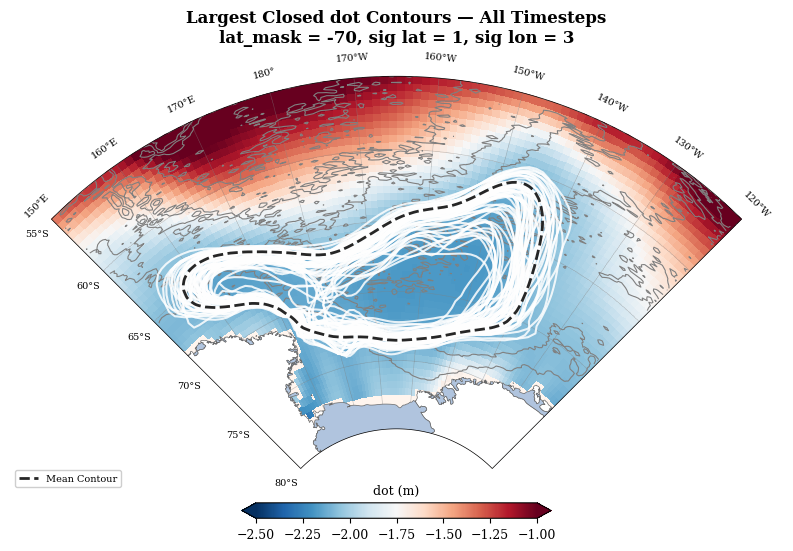

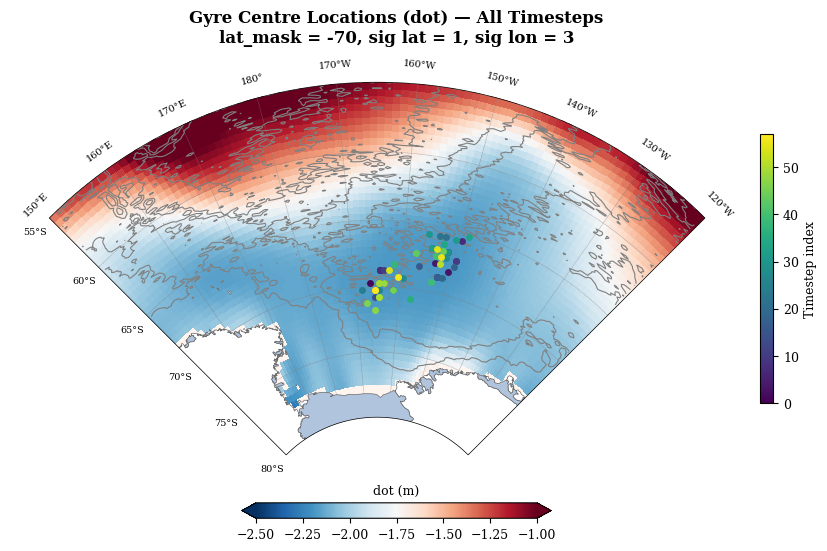

In [123]:
# ── Shared stereo base ────────────────────────────────────────────────────────
#spstere_plot_sector must return wedge_patch as 4th value
multiple = 5

plot_lat_min = np.round(np.min(lats/multiple))*multiple
plot_lat_max = np.round(np.max(lats/multiple))*multiple

# contours plot
if gyre_name == 'ross':
    fig, ax, m_sec, wedge_patch = st.spstere_plot_sector(
    lon_grid_ref, lat_grid_ref, var_mean,
    [-2.5, -1],
    'RdBu_r', f'{variable} (m)',
    lon_min=lon_min % 360,    # ensure 0–360 for Ross (140 stays 140)
    lon_max=lon_max % 360,    # -80 → 280
    lat_min=plot_lat_min,              # deep enough to contain the gyre
    lat_max=plot_lat_max,
    contours=True,
    contour_levels=[-5000, -4000, -3000, -2000, -1000],
    # contour_colors=['grey', 'grey', 'grey'],
    contour_lws=[0.8, 0.8, 0.8],
    # contour_linestyles=['-', '-', '-'],
    tglon=st.tglon, tglat=st.tglat, topo=st.topo
    )
    spstere_plot_gyre_contours(ax, m_sec, wedge_patch,
                                   to_plot, plot_mode=plot_mode, variable=variable, lat_mask_max=lat_mask_max, white_contours = True)

    spstere_mean_contour_plot(ax, m_sec, wedge_patch,mean_verts)

    # centres plot — new figure, same base
    fig, ax, m_sec, wedge_patch = st.spstere_plot_sector(
        lon_grid_ref, lat_grid_ref, var_mean,
        [-2.5, -1],
        'RdBu_r', f'{variable} (m)',
        lon_min=lon_min % 360,
        lon_max=lon_max % 360,
        lat_min=plot_lat_min,
        lat_max=plot_lat_max,
        contours=True,
        contour_levels=[-5000, -4000, -3000, -2000, -1000],
        # contour_colors=['pink', 'cyan', 'magenta'],
        contour_lws=[0.8, 0.8, 0.8],
        # contour_linestyles=[':', '-.', '--'],
        tglon=st.tglon, tglat=st.tglat, topo=st.topo
    )
    spstere_plot_gyre_centres(ax, m_sec, wedge_patch,
                                  gyre_centres, plot_mode=plot_mode, variable=variable)

    plt.show()

elif gyre_name == 'weddell' or gyre_name == 'kerguelen':
    fig, ax, m_sec, wedge_patch = st.spstere_plot_sector(
        lon_grid_ref, lat_grid_ref, var_mean,
        [-2.5, -0.5],
        'RdBu_r', f'{variable} (m)',
        lon_min=lon_min,    # ensure 0–360 for Ross (140 stays 140)
        lon_max=lon_max ,    # -80 → 280
        lat_min=plot_lat_min,              # deep enough to contain the gyre
        lat_max=plot_lat_max,
        contours=True,
        contour_levels=[-5000, -4000, -3000, -2000, -1000],
        # contour_colors=['grey', 'grey', 'grey'],
        contour_lws=[0.8, 0.8, 0.8],
        # contour_linestyles=['-', '-', '-'],
        tglon=st.tglon, tglat=st.tglat, topo=st.topo
    )
    spstere_plot_gyre_contours(ax, m_sec, wedge_patch,
                                   to_plot, plot_mode=plot_mode, variable=variable, white_contours = True)
    spstere_mean_contour_plot(ax, m_sec, wedge_patch,mean_verts)
    plt.show()

    # centres plot — new figure, same base
    fig, ax, m_sec, wedge_patch = st.spstere_plot_sector(
        lon_grid_ref, lat_grid_ref, var_mean,
        [-2.5, -0.5],
        'RdBu_r', f'{variable} (m)',
        lon_min=lon_min ,
        lon_max=lon_max ,
        lat_min=plot_lat_min,
        lat_max=plot_lat_max,
        contours=True,
        contour_levels=[-5000, -4000, -3000, -2000, -1000],
        # contour_colors=['pink', 'cyan', 'magenta'],
        contour_lws=[0.8, 0.8, 0.8],
        # contour_linestyles=[':', '-.', '--'],
        tglon=st.tglon, tglat=st.tglat, topo=st.topo
    )
    spstere_plot_gyre_centres(ax, m_sec, wedge_patch,
                                  gyre_centres, plot_mode=plot_mode, variable=variable)
plt.show()

## calc gyre strength (original) using: S = max dot contour height -center

In [124]:
gyre_strength = []

for result, centre in zip(to_plot, gyre_centres):
    time_idx_i = result['time_idx']

    # --- Dateline-aware slice ---
    if not crosses_dateline:
        ds_i = ds.sel(longitude=slice(lon_min, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        lons_i   = ds_i['longitude'].values
        lats_i   = ds_i['latitude'].values
        # ssh_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan,
        #                     (ds_i['dot'] + ds_i['sla']).values.T)
        var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)
    else:
        ds_A = ds.sel(longitude=slice(lon_min, 180),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds.sel(longitude=slice(-180, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
        ds_i  = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
        lons_i   = ds_i['longitude'].values
        lats_i   = ds_i['latitude'].values
        # ssh_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan,
        #                     (ds_i['dot'] + ds_i['sla']).values.T)
        var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)

        land_2d_i  = ds_i['land_mask'].values.T
        total_mask = (land_2d_i == 0)
        var_filled = np.where(total_mask, var_2d_i, 0.0)
        weights    = np.where(total_mask, 1.0, 0.0)
        smoothed_vals    = gaussian_filter(var_filled, sigma=(lat_sigma, lon_sigma))
        smoothed_weights = gaussian_filter(weights,    sigma=(lat_sigma, lon_sigma))
        smoothed         = np.where(smoothed_weights > 0, smoothed_vals / smoothed_weights, np.nan)
        var_2d_smoothed  = np.where(total_mask, smoothed, var_2d_i)
        var_2d_i         = np.where(land_2d_i == 1, np.nan, var_2d_smoothed)

    lon_grid_i, lat_grid_i = np.meshgrid(lons_i, lats_i)

    # --- Boundary variable (dot or sla): mean var at contour vertices ---
    verts_i      = result['verts']
    boundary_var = sample_field_at_vertices(verts_i, var_2d_i, lon_grid_i, lat_grid_i)

    # --- Centre dot: interpolate to minimum-var location ---
    # centre_dot = interpn(
    #     (lats_i, lons_i), dot_2d_i,
    #     (centre['centre_lat'], centre['centre_lon']),
    #     method='linear', bounds_error=False, fill_value=np.nan
    # )

    centre_var = interpn(
    (lats_i, lons_i), var_2d_i,
    np.array([[centre['centre_lat'], centre['centre_lon']]]),
    method='linear', bounds_error=False, fill_value=np.nan)[0]

    strength = float(boundary_var - centre_var)

    gyre_strength.append({
        'time'        : result['time'],
        'time_idx'    : time_idx_i,
        'boundary_var': float(boundary_var),
        'centre_var'  : float(centre_var),
        'strength'    : strength,
    })

print(f"Gyre strength computed for {len(gyre_strength)} timesteps.")

Gyre strength computed for 58 timesteps.


In [125]:
## calc gyre strength (norm) using: S = (max dot contour height -center)/ Mean radius

In [126]:
gyre_strength = []

for result, centre in zip(to_plot, gyre_centres):
    time_idx_i = result['time_idx']

    # --- Dateline-aware slice ---
    if not crosses_dateline:
        ds_i = ds.sel(longitude=slice(lon_min, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        lons_i   = ds_i['longitude'].values
        lats_i   = ds_i['latitude'].values
        # ssh_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan,
        #                     (ds_i['dot'] + ds_i['sla']).values.T)
        var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)
    else:
        ds_A = ds.sel(longitude=slice(lon_min, 180),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds.sel(longitude=slice(-180, lon_max),
                      latitude=slice(lat_min, lat_max),
                      time=ds.time[time_idx_i])
        ds_B = ds_B.assign_coords(longitude=ds_B.longitude.values + 360)
        ds_i  = xr.concat([ds_A, ds_B], dim='longitude', data_vars='all')
        lons_i   = ds_i['longitude'].values
        lats_i   = ds_i['latitude'].values
        # ssh_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan,
        #                     (ds_i['dot'] + ds_i['sla']).values.T)
        var_2d_i = np.where(ds_i['land_mask'].values.T == 1, np.nan, ds_i[variable].values.T)

        land_2d_i  = ds_i['land_mask'].values.T
        total_mask = (land_2d_i == 0)
        var_filled = np.where(total_mask, var_2d_i, 0.0)
        weights    = np.where(total_mask, 1.0, 0.0)
        smoothed_vals    = gaussian_filter(var_filled, sigma=(lat_sigma, lon_sigma))
        smoothed_weights = gaussian_filter(weights,    sigma=(lat_sigma, lon_sigma))
        smoothed         = np.where(smoothed_weights > 0, smoothed_vals / smoothed_weights, np.nan)
        var_2d_smoothed  = np.where(total_mask, smoothed, var_2d_i)
        var_2d_i         = np.where(land_2d_i == 1, np.nan, var_2d_smoothed)

    lon_grid_i, lat_grid_i = np.meshgrid(lons_i, lats_i)

    # --- Boundary variable (dot or sla): mean var at contour vertices ---
    verts_max = result['verts']
    verts_min = result['min_verts']

    dot_max = sample_field_at_vertices(verts_max, var_2d_i, lon_grid_i, lat_grid_i)
    dot_min = sample_field_at_vertices(verts_min, var_2d_i, lon_grid_i, lat_grid_i)
    boundary_var = dot_max


    # --- Centre dot: interpolate to minimum-var location ---
    # centre_dot = interpn(
    #     (lats_i, lons_i), dot_2d_i,
    #     (centre['centre_lat'], centre['centre_lon']),
    #     method='linear', bounds_error=False, fill_value=np.nan
    # )

    # use cKDTree to find the nearest neighbour between the min and max contours (this is needed to calculate R)

    ckdtree = cKDTree(verts_max)
    dists_deg, nearest_neighbour_index = ckdtree.query(verts_min)
    lon1 = np.deg2rad(verts_min[:,0])
    lat1 = np.deg2rad(verts_min[:,1])
    lon2 = np.deg2rad(verts_max[nearest_neighbour_index,0])
    lat2 = np.deg2rad(verts_max[nearest_neighbour_index,1])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # haversine formula
    a = np.sin(dlat/2)**2
    b= np.cos(lat1)*np.cos(lat2)
    c = np.sin(dlon/2)**2

    R_earth = 6371

    dists_km = 2*R_earth*np.arcsin(np.sqrt(a+b*c))
    mean_R_km = np.mean(dists_km)

    centre_var = interpn(
    (lats_i, lons_i), var_2d_i,
    np.array([[centre['centre_lat'], centre['centre_lon']]]),
    method='linear', bounds_error=False, fill_value=np.nan)[0]

    strength_original = float(boundary_var - centre_var)
    if mean_R_km > 0.05:
        strength_normalised = float((dot_max - dot_min)/mean_R_km)
    else:
        strength_normalised = np.nan


    gyre_strength.append({
        'time'        : result['time'],
        'time_idx'    : time_idx_i,
        'boundary_var': float(boundary_var),
        'centre_var'  : float(centre_var),
        'strength_original'    : strength_original,
        'strength_normalised' : strength_normalised,
        'mean_R_km' : float(mean_R_km),
    })

print(f"Gyre strength using mean R computed for {len(gyre_strength)} timesteps.")

Gyre strength using mean R computed for 58 timesteps.


## plot timeseries (can be edited for single TS)

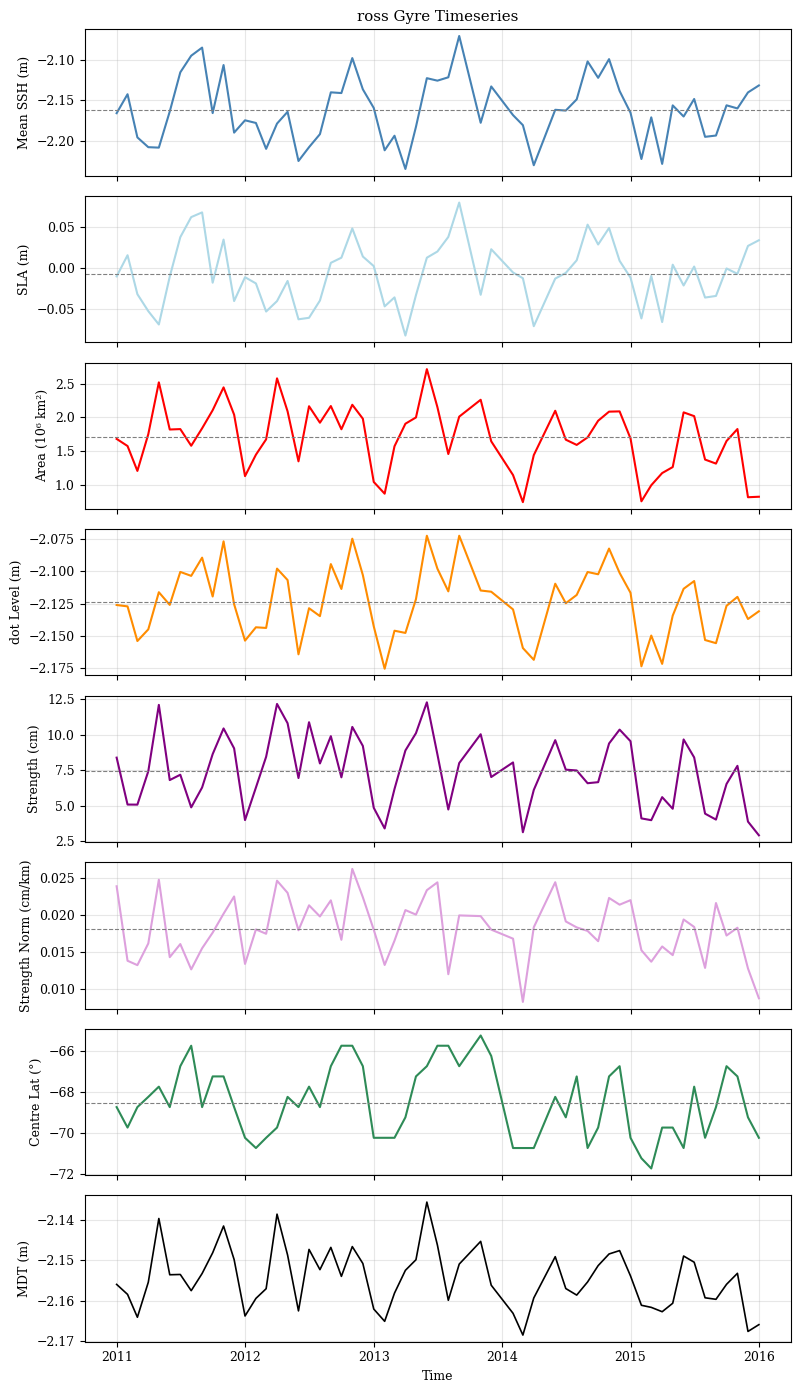

In [127]:
times     = [r['time']     for r in to_plot]
areas     = [r['area']     for r in to_plot]
levels    = [r['level']    for r in to_plot]
ssh_vals  = [r['ssh_mean'] for r in to_plot]
mdt_vals  = [r['mdt_mean'] for r in to_plot]
sla_vals  = np.array(ssh_vals) - np.array(mdt_vals)
strength_original   = [r['strength_original']   for r in gyre_strength]
strength_normalised = [r['strength_normalised'] for r in gyre_strength]
centre_lats = [r['centre_lat'] for r in gyre_centres]
areas_km2   = [r['area_km2'] / 1e6 for r in to_plot]

# 8 subplots now
fig, axes = plt.subplots(8, 1, figsize=(8, 14), sharex=True)


axes[0].plot(times, ssh_vals, color='steelblue', linewidth=1.5)
axes[0].axhline(np.nanmean(ssh_vals), color='gray', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('Mean SSH (m)')
axes[0].set_title(f'{gyre_name} Gyre Timeseries')
axes[0].grid(True, alpha=0.3)


axes[1].plot(times, sla_vals, color='lightblue', linewidth=1.5)
axes[1].axhline(np.nanmean(sla_vals), color='gray', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('SLA (m)')
axes[1].grid(True, alpha=0.3)


axes[2].plot(times, areas_km2, color='red', linewidth=1.5)
axes[2].axhline(np.nanmean(areas_km2), color='gray', linewidth=0.8, linestyle='--')
axes[2].set_ylabel('Area (10⁶ km²)')
axes[2].grid(True, alpha=0.3)


axes[3].plot(times, levels, color='darkorange', linewidth=1.5)
axes[3].axhline(np.nanmean(levels), color='gray', linewidth=0.8, linestyle='--')
axes[3].set_ylabel(f'{variable} Level (m)')
axes[3].grid(True, alpha=0.3)


axes[4].plot(times, np.array(strength_original)*1e2, color='purple', linewidth=1.5)
axes[4].axhline(np.nanmean(strength_original)*1e2, color='gray', linewidth=0.8, linestyle='--')
axes[4].set_ylabel('Strength (cm)')
axes[4].grid(True, alpha=0.3)


axes[5].plot(times, np.array(strength_normalised)*1e2, color='plum', linewidth=1.5)
axes[5].axhline(np.nanmean(strength_normalised)*1e2, color='gray', linewidth=0.8, linestyle='--')
axes[5].set_ylabel('Strength Norm (cm/km)')
axes[5].grid(True, alpha=0.3)

axes[6].plot(times, centre_lats, color='seagreen', linewidth=1.5)
axes[6].axhline(np.nanmean(centre_lats), color='gray', linewidth=0.8, linestyle='--')
axes[6].set_ylabel('Centre Lat (°)')
axes[6].grid(True, alpha=0.3)


axes[7].plot(times, mdt_vals, color='black', linewidth=1.2)
axes[7].set_ylabel('MDT (m)')
axes[7].set_xlabel('Time')
axes[7].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## calc R and P values for SAM - parameter relationships

In [128]:
times_np = np.array(times)  # ensure it's a numpy array

years_t  = times_np.astype('datetime64[Y]').astype(int) + 1970
months_t = times_np.astype('datetime64[M]').astype(int) % 12 + 1

# Build SAM lookup dictionary
sam_lookup = {
    (year, month+1): sam_ind[i, month]
    for i, year in enumerate(sam_yrs)
    for month in range(12)
}

# Extract SAM values aligned to your gyre times
sam_for_times = np.array([
    sam_lookup.get((y, m), np.nan)
    for y, m in zip(years_t, months_t)
])

from scipy.stats import pearsonr

mask = ~np.isnan(sam_for_times)
print(mask.shape)

corr_ssh, p_ssh = pearsonr(sam_for_times[mask], np.array(ssh_vals)[mask])
corr_area, p_area = pearsonr(sam_for_times[mask], np.array(areas_km2)[mask])
corr_level, p_level = pearsonr(sam_for_times[mask], np.array(levels)[mask])
corr_strength_orig, p_strength_orig = pearsonr(sam_for_times[mask], np.array(strength_original)[mask])
corr_strength_norm, p_strength_norm = pearsonr(sam_for_times[mask], np.array(strength_normalised)[mask])
corr_lat, p_lat = pearsonr(sam_for_times[mask], np.array(centre_lats)[mask])


(58,)


## plot TS for full timeseries defined at top of notebook with SAM r and p values

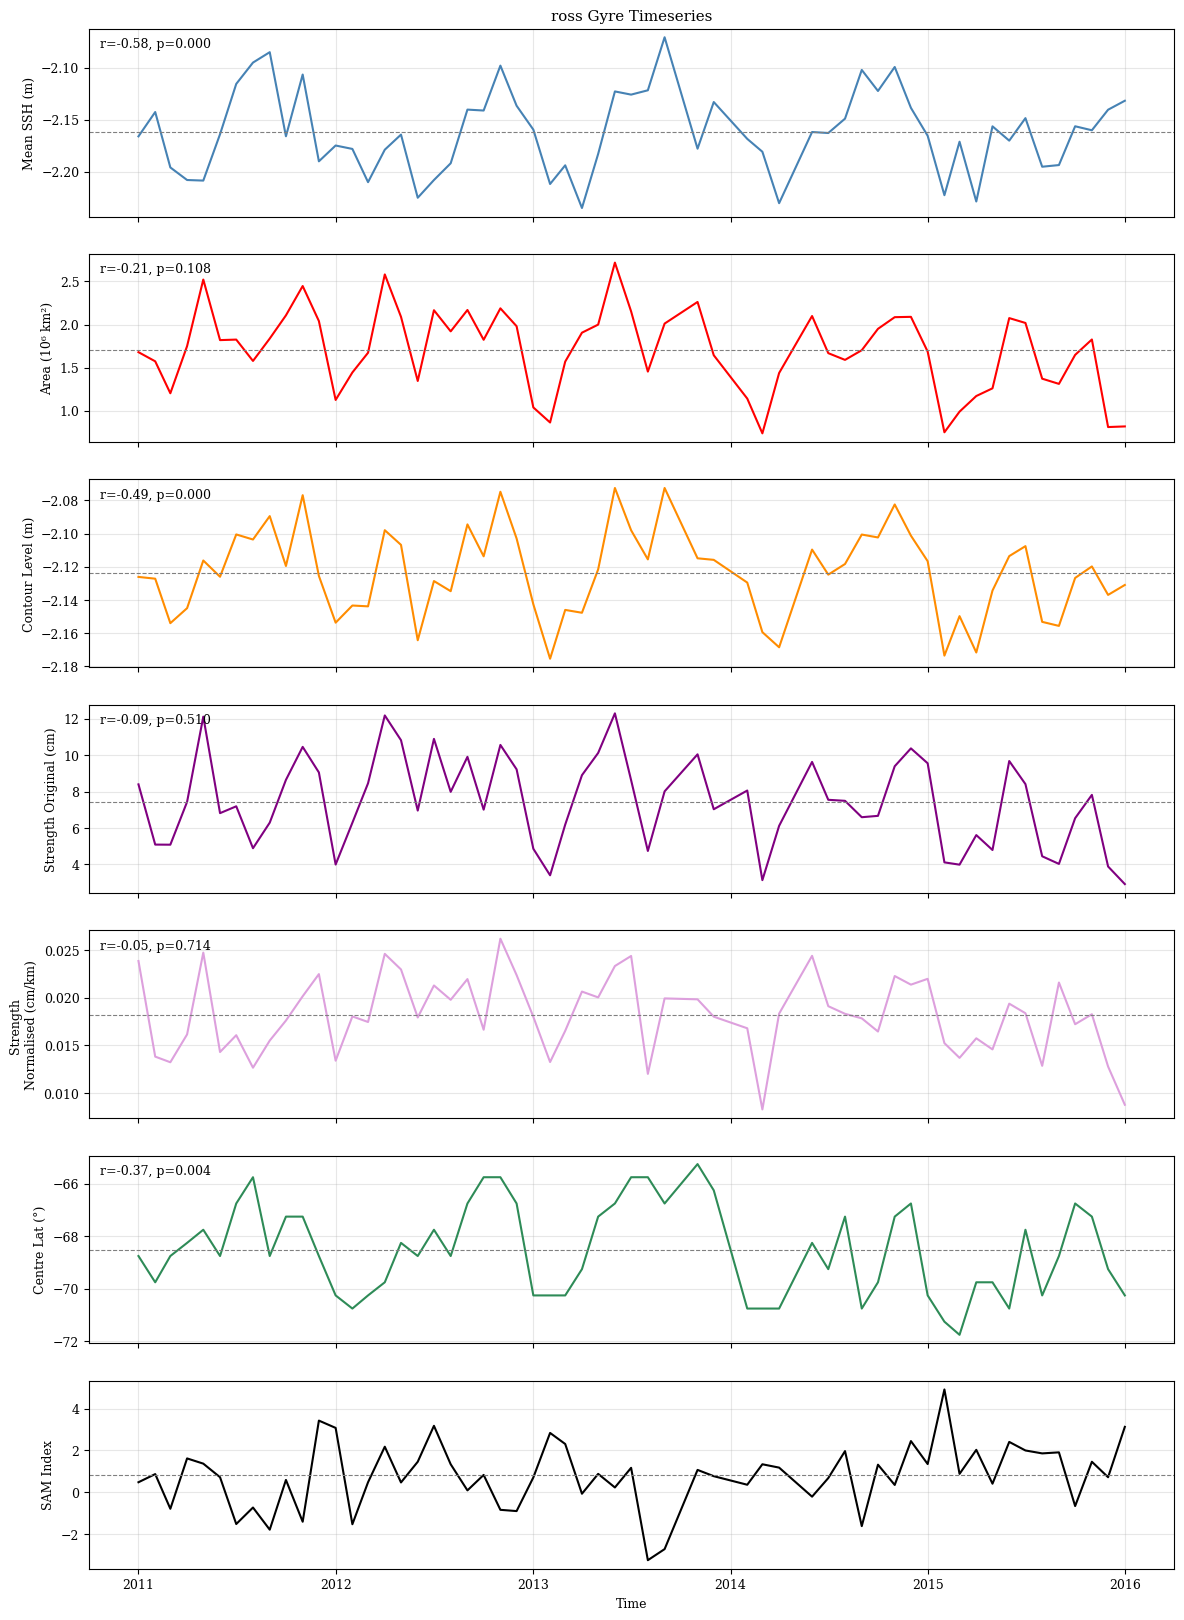

In [129]:
# ---------------------------------------------------------
# 1. Extract year + month from numpy.datetime64 timestamps
# ---------------------------------------------------------

times_np = np.array(times)

years_t  = times_np.astype('datetime64[Y]').astype(int) + 1970
months_t = times_np.astype('datetime64[M]').astype(int) % 12 + 1

# ---------------------------------------------------------
# 2. Build SAM lookup dictionary
#    (year, month) → SAM value
# ---------------------------------------------------------

sam_lookup = {}
for i, year in enumerate(sam_yrs):
    for m in range(12):  # m = 0..11
        sam_lookup[(year, m+1)] = sam_ind[i, m]

# ---------------------------------------------------------
# 3. Align SAM to gyre times
# ---------------------------------------------------------

sam_for_times = np.array([
    sam_lookup.get((y, m), np.nan)
    for y, m in zip(years_t, months_t)
])

# ---------------------------------------------------------
# 4. Compute correlations (no helper function)
# ---------------------------------------------------------

mask = ~np.isnan(sam_for_times)

corr_ssh, p_ssh = pearsonr(sam_for_times[mask], np.array(ssh_vals)[mask])
corr_area, p_area = pearsonr(sam_for_times[mask], np.array(areas_km2)[mask])
corr_level, p_level = pearsonr(sam_for_times[mask], np.array(levels)[mask])
corr_strength_orig, p_strength_orig = pearsonr(sam_for_times[mask], np.array(strength_original)[mask])
corr_strength_norm, p_strength_norm = pearsonr(sam_for_times[mask], np.array(strength_normalised)[mask])
corr_lat, p_lat = pearsonr(sam_for_times[mask], np.array(centre_lats)[mask])

# ---------------------------------------------------------
# 5. Plot 6‑panel figure
# ---------------------------------------------------------

fig, axes = plt.subplots(7, 1, figsize=(14, 20), sharex=True)

# Panel 1 — SSH
axes[0].plot(times, ssh_vals, color='steelblue', linewidth=1.5)
axes[0].axhline(np.nanmean(ssh_vals), color='gray', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('Mean SSH (m)')
axes[0].set_title(f'{gyre_name} Gyre Timeseries')
axes[0].grid(alpha=0.3)
axes[0].text(0.01, 0.9, f"r={corr_ssh:.2f}, p={p_ssh:.3f}", transform=axes[0].transAxes)

# Panel 2 — Area
axes[1].plot(times, areas_km2, color='red', linewidth=1.5)
axes[1].axhline(np.nanmean(areas_km2), color='gray', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('Area (10⁶ km²)')
axes[1].grid(alpha=0.3)
axes[1].text(0.01, 0.9, f"r={corr_area:.2f}, p={p_area:.3f}", transform=axes[1].transAxes)

# Panel 3 — Contour Level
axes[2].plot(times, levels, color='darkorange', linewidth=1.5)
axes[2].axhline(np.nanmean(levels), color='gray', linestyle='--', linewidth=0.8)
axes[2].set_ylabel('Contour Level (m)')
axes[2].grid(alpha=0.3)
axes[2].text(0.01, 0.9, f"r={corr_level:.2f}, p={p_level:.3f}", transform=axes[2].transAxes)

# Panel 4 — Strength
axes[3].plot(times, np.array(strength_original)*1e2, color='purple', linewidth=1.5)
axes[3].axhline(np.nanmean(strength_original)*1e2, color='gray', linestyle='--', linewidth=0.8)
axes[3].set_ylabel('Strength Original (cm)')
axes[3].grid(alpha=0.3)
axes[3].text(0.01, 0.9, f"r={corr_strength_orig:.2f}, p={p_strength_orig:.3f}", transform=axes[3].transAxes)

axes[4].plot(times, np.array(strength_normalised)*1e2, color='plum', linewidth=1.5)
axes[4].axhline(np.nanmean(strength_normalised)*1e2, color='gray', linestyle='--', linewidth=0.8)
axes[4].set_ylabel('Strength \nNormalised (cm/km)')
axes[4].grid(alpha=0.3)
axes[4].text(0.01, 0.9, f"r={corr_strength_norm:.2f}, p={p_strength_norm:.3f}", transform=axes[4].transAxes)

# Panel 6 — Centre Latitude
axes[5].plot(times, centre_lats, color='seagreen', linewidth=1.5)
axes[5].axhline(np.nanmean(centre_lats), color='gray', linestyle='--', linewidth=0.8)
axes[5].set_ylabel('Centre Lat (°)')
axes[5].grid(alpha=0.3)
axes[5].text(0.01, 0.9, f"r={corr_lat:.2f}, p={p_lat:.3f}", transform=axes[5].transAxes)

# Panel 7 — SAM Index
axes[6].plot(times, sam_for_times, color='black', linewidth=1.5)
axes[6].axhline(np.nanmean(sam_for_times), color='gray', linestyle='--', linewidth=0.8)
axes[6].set_ylabel('SAM Index')
axes[6].set_xlabel('Time')
axes[6].grid(alpha=0.3)

# plt.tight_layout()
plt.show()
